# CIFAR-10 STAQ

A notebook for the CIFAR-10 STAQ workflow:

- load config, CLIP, concepts, and data
- load or train Concept-QA
- load or train baseline VIP and STAQ
- probe the sensitive concept set before retraining
- check sample-level sensitive-label sanity
- replay tiny-start cases
- mine confidence-stop contrasts

In [ ]:
%pip install -e ..

In [18]:
%load_ext autoreload
%autoreload 2
import json
from pathlib import Path

import torch

from staq.analysis import (
    mine_confidence_stop_contrasts,
    plot_rollout_comparisons,
    probe_topk_sensitive_queries,
    sample_intuition_replays,
)
from staq.config import Cifar10StaqConfig, default_paths
from staq.core import (
    build_concept_dictionary,
    concept_answers_batch,
    load_clip_model,
    load_concept_qa_checkpoint,
    load_concepts,
    load_vip_bundle,
    make_sensitive_mask,
    save_bundle_checkpoint,
)
from staq.data import get_cifar10_datasets, get_cifar10_loaders, get_raw_cifar10_dataset
from staq.models import ConceptNet2
from staq.sensitive_labels import (
    build_cifar10_sensitive_match,
    build_sensitive_labels,
    load_sensitive_labels,
    save_sensitive_labels,
)
from staq.training import HistorySamplingConfig, build_staq_models, fit_concept_qa, fit_staq, seed_everything
from staq.training.concept_qa import load_gpt_answers

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
repo_root = Path.cwd().resolve()
if not (repo_root / "staq").exists() and (repo_root.parent / "staq").exists():
    repo_root = repo_root.parent

paths = default_paths(repo_root=repo_root)
paths.ensure_artifact_dirs()

config = Cifar10StaqConfig()
device = config.device
seed_everything(config.random_seed)

print(f"repo_root: {repo_root}")
print(f"artifacts_root: {paths.artifacts_root}")
print(f"device: {device}")

repo_root: /Users/amir.atashin/Projects/conceptqa_vip-main
artifacts_root: /Users/amir.atashin/Projects/conceptqa_vip-main/artifacts
device: cpu


In [20]:
model_clip, preprocess = load_clip_model(config.clip_model_name, device=device)
concepts = load_concepts(paths.concept_file)
dictionary = build_concept_dictionary(model_clip=model_clip, concepts=concepts, device=device)
sensitive_match = build_cifar10_sensitive_match(concepts)
sens_idx = sensitive_match.indices
sensitive_mask = make_sensitive_mask(config.max_queries, sens_idx, device)

train_ds, test_ds = get_cifar10_datasets(transform=preprocess, root=paths.data_root)
train_loader, test_loader = get_cifar10_loaders(
    transform=preprocess,
    root=paths.data_root,
    batch_size=config.batch_size,
    num_workers=config.num_workers,
)
raw_test_ds = get_raw_cifar10_dataset(paths.data_root, train=False)

print(f"# concepts: {len(concepts)}")
print(f"# sensitive concepts matched: {len(sensitive_match.matched)}")
print(sensitive_match.matched)
if sensitive_match.missing:
    print(f"# sensitive concepts missing: {len(sensitive_match.missing)}")
    print(sensitive_match.missing)

# concepts: 128
# sensitive concepts matched: 23
['a bridle', 'a cab for the driver', 'a captain', 'a collar', 'a copilot', 'a dashboard', 'a driver', 'a flight attendant', 'a gear shift', 'a halter', 'a hitch', 'a lead rope', 'a leash', 'a passenger', 'a pedal', 'a pilot', 'a reins', 'a rider', 'a rifle', 'a saddle', 'a seatbelt', 'a steering wheel', 'a trailer']


In [21]:
qa_checkpoint = paths.checkpoints_root / "concept_qa_cifar10.pt"
qa_source = qa_checkpoint
if qa_checkpoint.exists():
    answering_model = load_concept_qa_checkpoint(qa_checkpoint, device=device)
elif paths.bootstrap_concept_qa_checkpoint.exists():
    answering_model = load_concept_qa_checkpoint(paths.bootstrap_concept_qa_checkpoint, device=device)
    qa_source = paths.bootstrap_concept_qa_checkpoint
elif paths.gpt_answers_file.exists():
    gpt_answers = load_gpt_answers(paths.gpt_answers_file)
    qa_model = ConceptNet2().to(device)
    qa_optimizer = torch.optim.SGD(qa_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    qa_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(qa_optimizer, T_max=200)
    qa_history = fit_concept_qa(
        model=qa_model,
        train_loader=train_loader,
        eval_loader=test_loader,
        optimizer=qa_optimizer,
        scheduler=qa_scheduler,
        num_epochs=2,
        model_clip=model_clip,
        dictionary=dictionary,
        gpt_answers=gpt_answers,
        clip_device=device,
        train_device=device,
    )
    torch.save(qa_model.state_dict(), qa_checkpoint)
    with open(paths.runs_root / "concept_qa_cifar10_history.json", "w", encoding="utf-8") as handle:
        json.dump(qa_history, handle, indent=2)
    answering_model = qa_model.eval()
else:
    raise FileNotFoundError("No local Concept-QA checkpoint, bootstrap checkpoint, or GPT answers file available.")

print(f"Concept-QA ready from: {qa_source}")

Concept-QA ready from: /Users/amir.atashin/Projects/conceptqa_vip-main/artifacts/checkpoints/bootstrap/concept_qa_cifar10_reference.pth


Ad-hoc sensitive-label sanity check for the sensitive set
{
  "tested_samples": 2560,
  "tau": 0.7,
  "topk": 3,
  "hard_positive_rate": 0.5609375238418579,
  "soft_mean": 0.7369790077209473,
  "soft_std": 0.123711958527565,
  "soft_quantiles": {
    "q05": 0.5507863581180572,
    "q25": 0.6352913826704025,
    "q50": 0.7232987284660339,
    "q75": 0.8497909903526306,
    "q95": 0.9300163060426712
  }
}


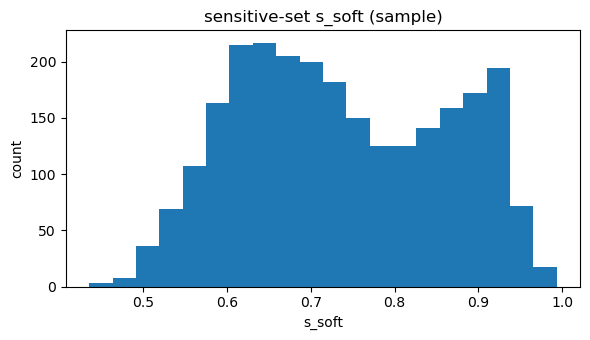

In [17]:
sensitive_labels_dir = paths.sensitive_labels_root

label_files = [
    sensitive_labels_dir / "s_soft_train.npy",
    sensitive_labels_dir / "s_hard_train.npy",
    sensitive_labels_dir / "s_soft_test.npy",
    sensitive_labels_dir / "s_hard_test.npy",
]

if all(path.exists() for path in label_files):
    sensitive_label_cache = load_sensitive_labels(sensitive_labels_dir)
    label_source = "cache"
else:
    s_soft_train, s_hard_train = build_sensitive_labels(
        loader=train_loader,
        model_clip=model_clip,
        dictionary=dictionary,
        sens_idx=sens_idx,
        clip_device=device,
        tau=config.sensitive_tau,
        topk=config.sensitive_topk,
    )
    s_soft_test, s_hard_test = build_sensitive_labels(
        loader=test_loader,
        model_clip=model_clip,
        dictionary=dictionary,
        sens_idx=sens_idx,
        clip_device=device,
        tau=config.sensitive_tau,
        topk=config.sensitive_topk,
    )
    save_sensitive_labels(
        sensitive_labels_dir,
        train_soft=s_soft_train,
        train_hard=s_hard_train,
        test_soft=s_soft_test,
        test_hard=s_hard_test,
    )
    sensitive_label_cache = load_sensitive_labels(sensitive_labels_dir)
    label_source = "built_and_saved"

print(f"Sensitive labels ready from: {label_source} -> {sensitive_labels_dir}")
print(
    {
        "s_soft_train": sensitive_label_cache["s_soft_train"].shape,
        "s_hard_train": sensitive_label_cache["s_hard_train"].shape,
        "s_soft_test": sensitive_label_cache["s_soft_test"].shape,
        "s_hard_test": sensitive_label_cache["s_hard_test"].shape,
    }
)
print(
    "Hard-positive rate (train/test):",
    float(sensitive_label_cache["s_hard_train"].mean()),
    float(sensitive_label_cache["s_hard_test"].mean()),
)

In [5]:
def load_or_train_run(
    run_name,
    lambda_adv,
    alpha_sens,
    min_history=config.min_history,
    max_history=config.max_history,
    non_sensitive_only=config.non_sensitive_history_only,
    epochs=2,
):
    ckpt_path = paths.checkpoints_root / f"{run_name}_best.pt"
    if ckpt_path.exists():
        return load_vip_bundle(ckpt_path, device=device, max_queries=config.max_queries, num_classes=config.num_classes)

    actor_checkpoint = str(paths.bootstrap_actor_checkpoint) if paths.bootstrap_actor_checkpoint.exists() else None
    classifier_checkpoint = str(paths.bootstrap_classifier_checkpoint) if paths.bootstrap_classifier_checkpoint.exists() else None

    actor, classifier, s_head = build_staq_models(
        max_queries=config.max_queries,
        num_classes=config.num_classes,
        device=device,
        actor_eps=config.actor_eps,
        actor_checkpoint=actor_checkpoint,
        classifier_checkpoint=classifier_checkpoint,
    )
    optimizer = torch.optim.Adam(
        list(actor.parameters()) + list(classifier.parameters()) + list(s_head.parameters()),
        lr=config.learning_rate,
    )
    history_config = HistorySamplingConfig(
        min_history=min_history,
        max_history=max_history,
        non_sensitive_only=non_sensitive_only,
    )
    history, best = fit_staq(
        actor=actor,
        classifier=classifier,
        s_head=s_head,
        optimizer=optimizer,
        train_loader=train_loader,
        test_loader=test_loader,
        model_clip=model_clip,
        dictionary=dictionary,
        answering_model=answering_model,
        sens_idx=sens_idx,
        history_config=history_config,
        clip_device=device,
        train_device=device,
        threshold_for_binarization=config.threshold_for_binarization,
        lambda_adv=lambda_adv,
        alpha_sens=alpha_sens,
        sensitive_tau=config.sensitive_tau,
        sensitive_topk=config.sensitive_topk,
        num_epochs=epochs,
        max_train_batches=60 if device.type == "cpu" else None,
        max_test_batches=30 if device.type == "cpu" else None,
    )
    save_bundle_checkpoint(
        checkpoint_path=ckpt_path,
        metadata={
            "run_name": run_name,
            "lambda_adv": lambda_adv,
            "alpha_sens": alpha_sens,
            "best_test_acc": best["test_acc"],
            "best_epoch": best["epoch"],
            "history_config": {
                "min_history": history_config.min_history,
                "max_history": history_config.max_history,
                "non_sensitive_only": history_config.non_sensitive_only,
            },
            "actor_state_dict": best["actor_state_dict"],
            "classifier_state_dict": best["classifier_state_dict"],
            "s_head_state_dict": best["s_head_state_dict"],
        },
    )
    with open(paths.runs_root / f"{run_name}_history.json", "w", encoding="utf-8") as handle:
        json.dump(history, handle, indent=2)
    return load_vip_bundle(ckpt_path, device=device, max_queries=config.max_queries, num_classes=config.num_classes)


baseline_bundle = load_or_train_run("baseline_vip", lambda_adv=0.0, alpha_sens=0.0)
staq_bundle = load_or_train_run("lam_0.80", lambda_adv=0.8, alpha_sens=0.0, epochs=20)

print(baseline_bundle["ckpt_path"])
print(staq_bundle["ckpt_path"])

def answer_builder(images):
    return concept_answers_batch(
        images=images,
        model_clip=model_clip,
        dictionary=dictionary,
        answering_model=answering_model,
        clip_device=device,
        train_device=device,
        threshold=config.threshold_for_binarization,
    )

/Users/amir.atashin/Projects/conceptqa_vip-main/artifacts/checkpoints/baseline_vip_best.pt
/Users/amir.atashin/Projects/conceptqa_vip-main/artifacts/checkpoints/lam_0.80_best.pt


In [6]:
intuition_records = sample_intuition_replays(
    dataset=test_ds,
    answer_builder=answer_builder,
    baseline_bundle=baseline_bundle,
    staq_bundle=staq_bundle,
    concepts=concepts,
    sensitive_mask=sensitive_mask,
    class_names=raw_test_ds.classes,
    num_cases=6,
    pool_size=400 if device.type == "cpu" else 1500,
    num_trials=3,
    min_history=0,
    max_history=1,
    history_mode="non_sensitive",
    prefer_baseline_sensitive=True,
)

intuition_fig = plot_rollout_comparisons(
    records=intuition_records,
    raw_dataset=raw_test_ds,
    output_path=paths.figures_root / "cifar10_intuition_replay_examples.png",
    title_prefix="tiny-start replay",
)

print(f"Saved tiny-start replay figure: {intuition_fig}")

Sampling intuition replays: 100%|██████████| 400/400 [00:19<00:00, 20.42it/s]


Saved tiny-start replay figure: /Users/amir.atashin/Projects/conceptqa_vip-main/artifacts/figures/cifar10_intuition_replay_examples.png


In [ ]:
# Superseded by the dataset-based contrast cell below.
# Keep only one contrast mining path in use to avoid overwriting outputs.

plot_records = contrast_result["plot_candidates"] if contrast_result["plot_candidates"] else contrast_result["selected_candidates"]
plot_warning = None
if not contrast_result["plot_candidates"] and contrast_result["selected_candidates"]:
    plot_warning = "Showing weak fallback examples only."

contrast_fig = None
if plot_records:
    contrast_fig = plot_rollout_comparisons(
        records=plot_records,
        raw_dataset=raw_test_ds,
        output_path=paths.figures_root / "cifar10_confidence_stop_contrasts.png",
        title_prefix="confidence-stop contrast",
        bucket_name=contrast_result["plot_bucket"] if contrast_result["plot_candidates"] else contrast_result["selected_bucket"],
        warning=plot_warning,
    )

with open(paths.runs_root / "cifar10_confidence_stop_contrasts.json", "w", encoding="utf-8") as handle:
    json.dump(
        {
            "stats": contrast_result["stats"],
            "bucket_counts": contrast_result["bucket_counts"],
            "selected_bucket": contrast_result["selected_bucket"],
            "plot_bucket": contrast_result["plot_bucket"],
            "selected_candidates": contrast_result["selected_candidates"],
        },
        handle,
        indent=2,
    )

print("bucket_counts:", contrast_result["bucket_counts"])
print("stats:", contrast_result["stats"])
if contrast_fig is None:
    print("No contrast figure was created because the miner found no plotable candidates.")
else:
    print(f"Saved contrast figure: {contrast_fig}")

In [16]:
contrast_result = mine_confidence_stop_contrasts(
    dataset=test_ds,
    answer_builder=answer_builder,
    baseline_bundle=baseline_bundle,
    staq_bundle=staq_bundle,
    concepts=concepts,
    sensitive_mask=sensitive_mask,
    class_names=raw_test_ds.classes,
    threshold=config.confidence_threshold,
    max_steps=config.confidence_max_steps,
    search_preset="tiny_auto",
    max_search_samples=400 if device.type == "cpu" else None,
    num_trials=4,
)

plot_records = contrast_result["plot_candidates"] if contrast_result["plot_candidates"] else contrast_result["selected_candidates"]
plot_warning = None
if not contrast_result["plot_candidates"] and contrast_result["selected_candidates"]:
    plot_warning = "Showing weak fallback examples only."

contrast_fig = None
if plot_records:
    contrast_fig = plot_rollout_comparisons(
        records=plot_records,
        raw_dataset=raw_test_ds,
        output_path=paths.figures_root / "cifar10_confidence_stop_contrasts.png",
        title_prefix="confidence-stop contrast",
        bucket_name=contrast_result["plot_bucket"] if contrast_result["plot_candidates"] else contrast_result["selected_bucket"],
        warning=plot_warning,
    )

with open(paths.runs_root / "cifar10_confidence_stop_contrasts.json", "w", encoding="utf-8") as handle:
    json.dump(
        {
            "stats": contrast_result["stats"],
            "bucket_counts": contrast_result["bucket_counts"],
            "search_plan": contrast_result["search_plan"],
            "selected_bucket": contrast_result["selected_bucket"],
            "plot_bucket": contrast_result["plot_bucket"],
            "selected_candidates": contrast_result["selected_candidates"],
        },
        handle,
        indent=2,
    )

print("search_plan:", contrast_result["search_plan"])
print("bucket_counts:", contrast_result["bucket_counts"])
print("stats:", contrast_result["stats"])
if contrast_fig is None:
    print("No contrast figure was created because the miner found no plotable candidates.")
else:
    print(f"Saved contrast figure: {contrast_fig}")

Mining confidence-stop contrasts: 0it [00:00, ?it/s]

Mining confidence-stop contrasts: 400it [00:24, 16.15it/s]

search_plan: [{'history_mode': 'non_sensitive', 'min_history': 0, 'max_history': 1}, {'history_mode': 'non_sensitive', 'min_history': 1, 'max_history': 2}, {'history_mode': 'random', 'min_history': 0, 'max_history': 1}, {'history_mode': 'random', 'min_history': 1, 'max_history': 2}]
bucket_counts: {'strict_zero_sensitive_staq': 0, 'both_correct_gap_positive': 0, 'all_gap_positive': 0, 'both_correct_delay_positive': 0, 'all_delay_positive': 0, 'both_correct_baseline_sensitive': 0, 'all_baseline_sensitive': 0}
stats: {'tested_states': 6400, 'both_stop_immediately': 99, 'baseline_any_sensitive': 0, 'staq_any_sensitive': 0, 'gap_positive': 0, 'both_correct_gap_positive': 0, 'strict_zero_sensitive_staq': 0, 'delay_positive': 0, 'both_correct_delay_positive': 0, 'baseline_sensitive_both_correct': 0}
No contrast figure was created because the miner found no plotable candidates.
